In [1]:
import sys
import warnings
import copy
import os
import subprocess
import tempfile
import yaml
from pathlib import Path, PurePath


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "scripts" / "run.py").is_file():
            return p
    raise RuntimeError(
        "Cannot find scripts/run.py. "
        "Use working directory CSIGen (repo root), CSIGen/examples, or CSIGen/examples/CSIGen."
    )


# Imports from repo (needs CSIGen root on sys.path)
REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from sionna.rt import load_scene, Receiver, subcarrier_frequencies

from src.base_station import set_tx_antenna_array, add_base_station
from src.user_equipment import set_rx_antenna_array
from src.utils import visualize_time_frequency_response, visualize_antenna_frequency_response

import numpy as np
import matplotlib.pyplot as plt


jitc_llvm_init(): LLVM API initialization failed ..


In [2]:
def normalize_channels(
    channels: np.ndarray,
    *,
    per_sample: bool = False,
    eps: float = 1e-30,
) -> np.ndarray:
    h = np.asarray(channels)

    if not np.iscomplexobj(h):
        raise ValueError(f"`channels` must be complex; got dtype={h.dtype}")

    if per_sample:
        sample_axes = tuple(range(1, h.ndim))
        mean_power = np.mean(np.abs(h) ** 2, axis=sample_axes, keepdims=True)
        clipped = mean_power < eps
        if np.any(clipped):
            warnings.warn(
                f"{int(np.sum(clipped))} sample(s) near-zero power.",
                RuntimeWarning,
                stacklevel=2,
            )
    else:
        mean_power = np.mean(np.abs(h) ** 2)
        if mean_power < eps:
            warnings.warn(
                f"Global mean_power={mean_power:.3e} < eps.",
                RuntimeWarning,
                stacklevel=2,
            )

    mean_power = np.maximum(mean_power, eps)
    return (h / np.sqrt(mean_power)).astype(np.complex64, copy=False)


In [3]:
# YAML used for scripts/run.py (edit path or CUSTOM_CONFIG overrides)
CONFIG_PATH = REPO_ROOT / "config/pilotwimae_dataset_configs/eval/nyc_config_test.yaml"

CUSTOM_CONFIG = copy.deepcopy(yaml.safe_load(CONFIG_PATH.read_text()))

# Mirrors the standalone realistic notebook defaults (urban NYC, modest deployment).
CUSTOM_CONFIG["num_deployment_buildings"] = 1
CUSTOM_CONFIG["tx_num_rows"] = 1
CUSTOM_CONFIG["tx_num_cols"] = 8
CUSTOM_CONFIG["num_sectors"] = 3
CUSTOM_CONFIG["num_user_samples_per_tx"] = 20

fd, cfg_path_str = tempfile.mkstemp(prefix="notebook_realistic_", suffix=".yaml", dir=str(REPO_ROOT / "examples"))
os.close(fd)

cfg_path = Path(cfg_path_str)
with open(cfg_path, "w") as f_out:
    yaml.dump(CUSTOM_CONFIG, f_out, sort_keys=False, allow_unicode=True)

print(f"Wrote notebook config: {cfg_path}")
subprocess.run(
    [sys.executable, str(REPO_ROOT / "scripts/run.py"), "--config", str(cfg_path)],
    cwd=str(REPO_ROOT),
    check=True,
)

Wrote notebook config: /home/berkay/Desktop/research/2026/CSIGen/examples/notebook_realistic__km06tqk.yaml


jitc_llvm_init(): LLVM API initialization failed ..
2026-05-17 19:45:28,271 - __main__ - INFO - Loading and validating configuration from /home/berkay/Desktop/research/2026/CSIGen/examples/notebook_realistic__km06tqk.yaml
2026-05-17 19:45:28,272 - src.config_validator - INFO - Loading configuration from /home/berkay/Desktop/research/2026/CSIGen/examples/notebook_realistic__km06tqk.yaml
2026-05-17 19:45:28,275 - src.config_validator - INFO - Configuration validation successful!
2026-05-17 19:45:28,275 - __main__ - INFO - Starting channel generation (streaming per TX)...
2026-05-17 19:45:28,275 - src.channel_generator - INFO - Step 1: Setting up scene...
2026-05-17 19:45:28,370 - src.scene_setup - INFO - Overrode ground material to itu_concrete
2026-05-17 19:45:28,377 - src.scene_setup - INFO - Building bounds: x=[-326.9, 363.5], y=[-316.2, 307.8]
2026-05-17 19:45:28,378 - src.utils - INFO - Clipped terrain: clamped 4479/14707 vertices to bounds
2026-05-17 19:45:28,378 - src.utils - INFO

2026-05-17 19:45:28 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


2026-05-17 19:45:30,014 - src.channel_generator - INFO - Step 5: Sampling user positions...
2026-05-17 19:45:30,024 - src.channel_generator - INFO - Step 5.5: Filtering positions by edge distance...
2026-05-17 19:45:30,025 - src.radio_map - INFO - Measurement surface bounds: x=[-341.9, 369.3], y=[-322.3, 322.6]
2026-05-17 19:45:30,025 - src.radio_map - INFO - Filtering users within 1.0 m of measurement surface edges...
2026-05-17 19:45:30,025 - src.radio_map - INFO -   TX 0: kept 18/20 users (removed 2)
2026-05-17 19:45:30,025 - src.radio_map - INFO -   TX 1: kept 20/20 users (removed 0)
2026-05-17 19:45:30,025 - src.radio_map - INFO -   TX 2: kept 17/20 users (removed 3)
2026-05-17 19:45:30,025 - src.radio_map - INFO - Filtering complete: 60 -> 55 users (removed 5)
2026-05-17 19:45:30,025 - src.radio_map - INFO - Final users per TX: 17
2026-05-17 19:45:30,025 - src.channel_generator - INFO - Step 6: Adding receivers...
2026-05-17 19:45:30,025 - src.receivers - INFO - Total TXs: 3, Use

Saved channel data to output/nyc_1/20260517_194528/channel_tx_0.npz
  Shape: (51, 1, 1, 8, 14, 32)
  Dtype: complex64
  Metadata keys: ['tx_idx', 'tx_name', 'tx_position', 'rx_positions', 'rx_names', 'los_binary', 'num_txs', 'num_users_per_tx', 'total_users', 'num_sectors', 'num_valid_channels', 'cfr_shape', 'cfr_dtype', 'config']


2026-05-17 19:45:44,709 - src.channel - INFO - Single TX CFR shape (51, 1, 1, 8, 14, 32)
2026-05-17 19:45:44,763 - __main__ - INFO - Saved channel data for TX 1 (BS_0_sector_2) to output/nyc_1/20260517_194528/channel_tx_1.npz (51 valid channels)
2026-05-17 19:45:44,763 - src.path_solver - INFO - TX 2 (BS_0_sector_3): Solving paths for all 51 users
2026-05-17 19:45:44,763 - src.path_solver - INFO - Solving paths for TX 2 (BS_0_sector_3) with 51 receivers
2026-05-17 19:45:44,763 - src.path_solver - INFO - Scene receivers: 51
2026-05-17 19:45:44,763 - src.path_solver - INFO - Scene transmitters: 1


Saved channel data to output/nyc_1/20260517_194528/channel_tx_1.npz
  Shape: (51, 1, 1, 8, 14, 32)
  Dtype: complex64
  Metadata keys: ['tx_idx', 'tx_name', 'tx_position', 'rx_positions', 'rx_names', 'los_binary', 'num_txs', 'num_users_per_tx', 'total_users', 'num_sectors', 'num_valid_channels', 'cfr_shape', 'cfr_dtype', 'config']


2026-05-17 19:45:51,692 - src.channel - INFO - Single TX CFR shape (51, 1, 1, 8, 14, 32)
2026-05-17 19:45:51,746 - __main__ - INFO - Saved channel data for TX 2 (BS_0_sector_3) to output/nyc_1/20260517_194528/channel_tx_2.npz (51 valid channels)
2026-05-17 19:45:51,749 - __main__ - INFO - Saved metadata summary to output/nyc_1/20260517_194528/metadata.yaml
2026-05-17 19:45:51,749 - __main__ - INFO - Channel generation and saving complete!
2026-05-17 19:45:51,749 - __main__ - INFO - Output directory: output/nyc_1/20260517_194528


Saved channel data to output/nyc_1/20260517_194528/channel_tx_2.npz
  Shape: (51, 1, 1, 8, 14, 32)
  Dtype: complex64
  Metadata keys: ['tx_idx', 'tx_name', 'tx_position', 'rx_positions', 'rx_names', 'los_binary', 'num_txs', 'num_users_per_tx', 'total_users', 'num_sectors', 'num_valid_channels', 'cfr_shape', 'cfr_dtype', 'config']


CompletedProcess(args=['/home/berkay/miniconda3/envs/sionna/bin/python', '/home/berkay/Desktop/research/2026/CSIGen/scripts/run.py', '--config', '/home/berkay/Desktop/research/2026/CSIGen/examples/notebook_realistic__km06tqk.yaml'], returncode=0)

In [4]:
_city = PurePath(str(CUSTOM_CONFIG["scene_xml_path"]))
city = _city.parent.name

out_root = REPO_ROOT / "output" / city
run_dirs = sorted(p for p in out_root.glob("*") if p.is_dir())
if not run_dirs:
    raise RuntimeError(f"No output runs under {out_root}")
data_dir = run_dirs[-1]
print(f"Using latest generation folder: {data_dir}")

dataset_name = "notebook_realistic_generated"
npz_files = sorted(
    data_dir.glob("channel_tx_*.npz"),
    key=lambda p: int(p.stem.rsplit("_", maxsplit=1)[-1]),
)

NUM_SECTORS = int(CUSTOM_CONFIG["num_sectors"])

# Select (BS, sector) pair
# each .npz file corresponds to a single (BS, sector) pair
BS_IDX = 0
SECTOR_IDX = 0
file_idx = BS_IDX * NUM_SECTORS + SECTOR_IDX

npz_file = npz_files[file_idx]
scene_xml_path = REPO_ROOT / "scenes" / city / "scene.xml"
print(f"Loading {npz_file.name} (BS_IDX={BS_IDX}, SECTOR_IDX={SECTOR_IDX}, file_idx={file_idx})")


Using latest generation folder: /home/berkay/Desktop/research/2026/CSIGen/output/nyc_1/20260517_194528
Loading channel_tx_0.npz (BS_IDX=0, SECTOR_IDX=0, file_idx=0)


In [5]:
with np.load(npz_file, allow_pickle=True) as data:
    print("The shape of the data is ", data["h"].shape)

    meta = data["metadata"].item()
    cfg = meta["config"]

    if "tx_num_rows" not in cfg or "tx_num_cols" not in cfg:
        raise RuntimeError("Expected tx antenna geometry in cfg.")
    if "subcarrier_spacing" not in cfg:
        raise RuntimeError("Expected subcarrier_spacing in cfg.")
    tx_name = meta.get("tx_name")
    if tx_name is None:
        raise RuntimeError("Expected tx_name in metadata.")

    n_rows = int(cfg["tx_num_rows"])
    n_cols = int(cfg["tx_num_cols"])
    subcarrier_spacing_hz = float(cfg["subcarrier_spacing"])
    carrier_frequency_hz = float(cfg["carrier_frequency"])

    print(f"Antenna array geometry: {n_rows}x{n_cols}")
    print(f"Subcarrier spacing: {subcarrier_spacing_hz / 1e3:.3f} kHz")
    print(f"Carrier frequency: {carrier_frequency_hz / 1e9:.3f} GHz")

    channels = np.squeeze(np.asarray(data["h"]))


carrier_frequency = float(cfg["carrier_frequency"])
subcarrier_spacing = float(cfg["subcarrier_spacing"])
ofdm_symbol_duration = 1.0 / subcarrier_spacing

print("Squeezed data shape:", channels.shape)
print("Loaded", channels.shape[0], "channels with shape", channels.shape[1:])


The shape of the data is  (51, 1, 1, 8, 14, 32)
Antenna array geometry: 1x8
Subcarrier spacing: 30.000 kHz
Carrier frequency: 28.000 GHz
Squeezed data shape: (51, 8, 14, 32)
Loaded 51 channels with shape (8, 14, 32)


In [6]:
print(f"There are {meta['los_binary'].sum()/meta['los_binary'].size*100:.1f}% LOS samples")

There are 49.0% LOS samples


In [7]:
# channels = normalize_channels(channels)

scene = load_scene(scene_xml_path, merge_shapes=True)
bs_base = f"BS_{BS_IDX}"

tx_position = meta.get("tx_position")
rx_positions = meta.get("rx_positions")
los_indices = np.where(meta["los_binary"] == 1)[0]
nlos_indices = np.where(meta["los_binary"] == 0)[0]


2026-05-17 19:45:52 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


In [8]:
set_tx_antenna_array(
    scene,
    num_rows=int(cfg["tx_num_rows"]),
    num_cols=int(cfg["tx_num_cols"]),
    vertical_spacing=float(cfg["tx_vertical_spacing"]),
    horizontal_spacing=float(cfg["tx_horizontal_spacing"]),
    pattern=str(cfg["tx_pattern"]),
    polarization=str(cfg["tx_polarization"]),
)

set_rx_antenna_array(
    scene,
    num_rows=int(cfg["rx_num_rows"]),
    num_cols=int(cfg["rx_num_cols"]),
    vertical_spacing=float(cfg["rx_vertical_spacing"]),
    horizontal_spacing=float(cfg["rx_horizontal_spacing"]),
    pattern=str(cfg["rx_pattern"]),
    polarization=str(cfg["rx_polarization"]),
)

print("Adding base station at ", tx_position)
add_base_station(
    scene,
    bs_base,
    position=list(tx_position),
    num_sectors=int(cfg["num_sectors"]),
    mechanical_tilt=float(cfg["mechanical_tilt"]),
    azimuth_offset=float(cfg["azimuth_offset"]),
    tx_power_dbm=float(cfg["tx_power_dbm"]),
    display_radius=15,
)

for user_idx in los_indices:
    rx = Receiver(
        name=f"UE_{user_idx}",
        position=list(rx_positions[user_idx]),
        display_radius=20,
        color=[0, 0, 1],
    )
    scene.add(rx)

for user_idx in nlos_indices:
    rx = Receiver(
        name=f"UE_{user_idx}",
        position=list(rx_positions[user_idx]),
        display_radius=20,
        color=[0, 1, 0],
    )
    scene.add(rx)

print(f"Added {len(los_indices)} LoS and {len(nlos_indices)} NLoS receivers for preview")


Adding base station at  [[-221.62103]
 [ 211.92195]
 [ 328.     ]]
Added 25 LoS and 26 NLoS receivers for preview


In [9]:
scene.preview()


In [10]:
# get subcarrier frequencies
freqs_hz = (
    subcarrier_frequencies(int(cfg["num_subcarriers"]), float(cfg["subcarrier_spacing"]))
    + float(cfg["carrier_frequency"])
)
print(freqs_hz[:3], "...", freqs_hz[-1])


[2.79995e+10, 2.79995e+10, 2.79996e+10] ... 28000450560.0


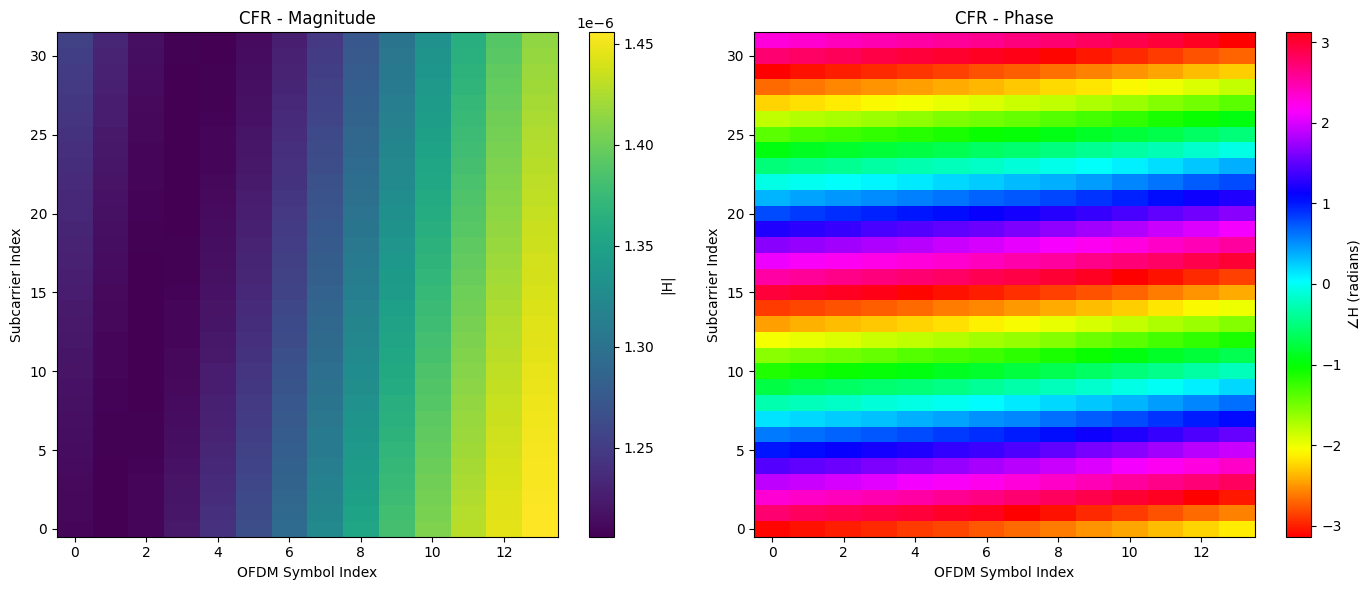

In [11]:
# Time-frequency response (subset of loaded CFR)
sample_rx_idx = 0
sample_tx_ant_idx = 0

# time-frequency response of the selected tx antenna at one user location
sample_channel = channels[sample_rx_idx, sample_tx_ant_idx, :, :]

fig = visualize_time_frequency_response(sample_channel, title="CFR")
plt.show()


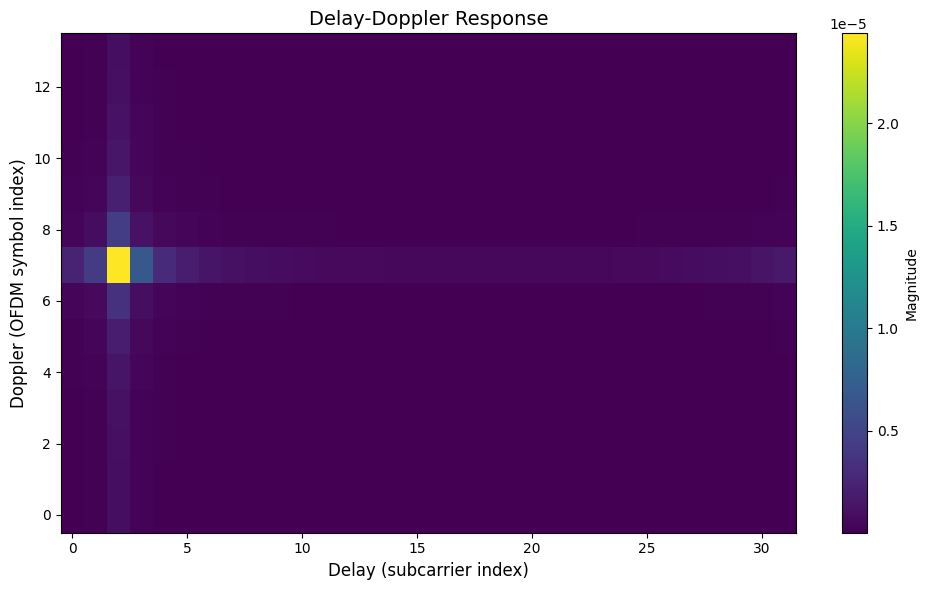

In [ ]:
# delay-Doppler view
_cfr_f = np.fft.fftshift(sample_channel, axes=1)  # ifft expects DC at zeroth index
_cfr_fdelay = np.fft.ifft(_cfr_f, axis=1, norm="ortho")  # ifft in frequency domain gives delay (time) domain
h_delay_doppler = np.fft.fft(_cfr_fdelay, axis=0, norm="ortho")  # fft in time domain gives frequency (doppler)domain
h_delay_doppler = np.fft.fftshift(h_delay_doppler, axes=0)  # make DC centered

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    np.abs(h_delay_doppler),
    aspect='auto',
    origin='lower',
    cmap='viridis',
    interpolation='nearest')
ax.set_xlabel('Delay (subcarrier index)', fontsize=12)
ax.set_ylabel('Doppler (OFDM symbol index)', fontsize=12)
ax.set_title('Delay-Doppler Response', fontsize=14)
plt.colorbar(im, ax=ax, label='Magnitude')
plt.tight_layout()
plt.show()


Reconstruction - max abs error: 5.08e-13, mean: 1.67e-13
Relative max error: 3.49e-07


NameError: name 'sample_tx_rx_cfr' is not defined

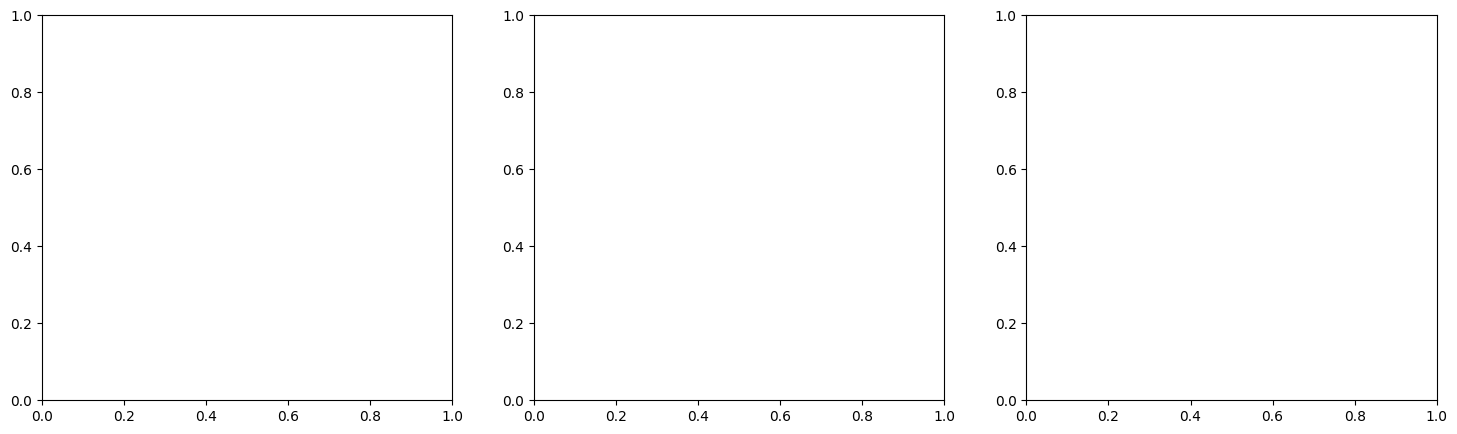

In [13]:
# Inverse transform sanity check on the CFR tensor used above

h_delay_doppler_unshifted = np.fft.ifftshift(h_delay_doppler, axes=0)
h_delay_recovered = np.fft.ifft(h_delay_doppler_unshifted, axis=0, norm="ortho")
h_recovered = np.fft.fft(h_delay_recovered, axis=1, norm="ortho")
cfr_recovered = np.fft.ifftshift(h_recovered, axes=1)

error = np.abs(cfr_recovered - sample_channel)
max_error = float(np.max(error))
mean_error = float(np.mean(error))
print(f"Reconstruction - max abs error: {max_error:.2e}, mean: {mean_error:.2e}")
print(
    "Relative max error:",
    f"{max_error / (np.max(np.abs(sample_channel)) + 1e-10):.2e}",
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
im1 = axes[0].imshow(np.abs(sample_tx_rx_cfr), aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Original CFR')
plt.colorbar(im1, ax=axes[0])
im2 = axes[1].imshow(np.abs(cfr_recovered), aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('Recovered CFR')
plt.colorbar(im2, ax=axes[1])
im3 = axes[2].imshow(error, aspect='auto', origin='lower', cmap='hot')
axes[2].set_title(f"Absolute error (max={max_error:.2e})")
plt.colorbar(im3, ax=axes[2])
plt.tight_layout()
plt.show()
